In [1]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
random.seed(333)
torch.manual_seed(333)
if device == 'cuda':
  torch.cuda.manual_seed(333)

In [3]:
# parameters
training_epochs = 20
batch_size = 100


In [4]:
# load the dataset
mnist_train = dsets.MNIST(root='MIST_data/',
                          train=True,
                          transform=transforms.ToTensor(),
                          download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting MIST_data/MNIST/raw/train-images-idx3-ubyte.gz to MIST_data/MNIST/raw



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting MIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MIST_data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

...

Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/MNIST/raw



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



In [5]:
# dataset loader
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          drop_last=True)

In [6]:
# MNIST data image of shape 28 * 28 =784
linear = torch.nn.Linear(784, 10, bias=True).to(device)

In [7]:
# define cost/loss & optimizer
criterion = torch.nn.CrossEntropyLoss().to(device) # Softmax is internally computed.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.05)

In [8]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for X, Y in data_loader:
    # reshape input image into [batch_size by 784]
    # label is not one-hot encoded
    X = X.view(-1, 28 * 28).to(device)  # (batch, 1, 28, 28) -> (batch, 784)
    Y = Y.to(device)

    optimizer.zero_grad()
    hypothesis = linear(X)
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    avg_cost += cost / total_batch

  print('Epoch:', '%01d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))


Epoch: 1 cost = 0.655285776
Epoch: 2 cost = 0.407584786
Epoch: 3 cost = 0.367762744
Epoch: 4 cost = 0.347056866
Epoch: 5 cost = 0.334164172
Epoch: 6 cost = 0.324803084
Epoch: 7 cost = 0.317524225
Epoch: 8 cost = 0.311940610
Epoch: 9 cost = 0.307360977
Epoch: 10 cost = 0.303292811
Epoch: 11 cost = 0.299853355
Epoch: 12 cost = 0.296918780
Epoch: 13 cost = 0.294441432
Epoch: 14 cost = 0.292212576
Epoch: 15 cost = 0.290036291
Epoch: 16 cost = 0.288205713
Epoch: 17 cost = 0.286353827
Epoch: 18 cost = 0.284933925
Epoch: 19 cost = 0.283410162
Epoch: 20 cost = 0.282038957


/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:67: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python3.7/dist-packages/torchvision/datasets/mnist.py:57: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Accuracy 0.8931999802589417
Label:  1
Prediction:  1


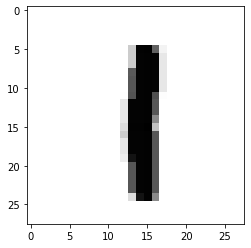

In [9]:
# test 할 때는 no_grad() 사용해서 gradient 계산하지 않는다.
# Test the model using test sets
with torch.no_grad():
  X_test = mnist_test.test_data.view(-1,28*28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  prediction = linear(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy', accuracy.item())

  # Set one and predict
  r = random.randint(0, len(mnist_test) - 1)
  X_single_data = mnist_test.test_data[r:r + 1].view(-1,28*28).float().to(device)
  Y_single_data = mnist_test.test_labels[r:r + 1].to(device)
  print('Label: ', Y_single_data.item())
  single_prediction = linear(X_single_data)
  print('Prediction: ', torch.argmax(single_prediction, 1).item())

  plt.imshow(mnist_test.test_data[r:r + 1].view(28, 28), cmap='Greys', interpolation='nearest')
  plt.show()
